In [1]:
%pip install pennylane --quiet

/home/prantik/projects/qsnippets/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

import torch
import torch.nn as nn
import pennylane as qml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# differentiable torch scalars during circuit execution.
warnings.filterwarnings(
    "ignore",
    message="Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.*",
    category=UserWarning,
)

classic_device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
class QuantumNet(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

    def set_device(self, device_type, shots=None):
        self.q_device = qml.device(device_type, wires=self.n_qubits, shots=shots)

    def make_circuit(self, layer_type):
        circuit, weight_shape = self._forward_layers(layer_type)
        self.layer = qml.qnn.TorchLayer(circuit, {"weights": weight_shape()})  # type: ignore

    def forward(self, x):
        return self.layer(x)

    def _forward_layers(self, layer_type):
        if layer_type == "strongly_entangling":
            return self.strongly_entangling_layers()
        elif layer_type == "cascading":
            return self.cascading_layers()
        elif layer_type == "alternating":
            return self.alternating_layers()
        elif layer_type == "cross_meshed":
            return self.cross_meshed_layers()
        else:
            raise ValueError(f"Invalid layer type: {layer_type}")

    def strongly_entangling_layers(self):
        def weight_shape():
            return qml.StronglyEntanglingLayers.shape(
                n_layers=self.n_layers, n_wires=self.n_qubits
            )

        @qml.qnode(self.q_device, interface="torch")
        def circuit(inputs, weights):
            self._set_angle_embedding(inputs)
            qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits))
            return self._measure_all()

        return circuit, weight_shape

    def cascading_layers(self):
        def weight_shape():
            return self._set_weight_shape(3)

        @qml.qnode(self.q_device, interface="torch")
        def circuit(inputs, weights):
            self._set_angle_embedding(inputs)

            for layer in range(self.n_layers):
                for wire in range(self.n_qubits):
                    qml.RX(weights[layer, wire, 0], wires=wire)
                    qml.RZ(weights[layer, wire, 1], wires=wire)

                for wire in range(self.n_qubits):
                    next_wire = (wire + 1) % self.n_qubits
                    qml.CRX(weights[layer, wire, 2], wires=[wire, next_wire])

            return self._measure_all()

        return circuit, weight_shape

    def alternating_layers(self):
        def weight_shape():
            sections = self.n_qubits // 2
            return (self.n_layers, 2, sections, 2, 2)

        @qml.qnode(self.q_device, interface="torch")
        def circuit(inputs, weights):
            self._set_angle_embedding(inputs)

            def add_gates(layer, sublayer, section, wire_control, wire_target):
                qml.RY(weights[layer, sublayer, section, 0, 0], wires=wire_control)
                qml.RY(weights[layer, sublayer, section, 0, 1], wires=wire_target)
                qml.CNOT(wires=[wire_control, wire_target])
                qml.RZ(weights[layer, sublayer, section, 1, 0], wires=wire_control)
                qml.RZ(weights[layer, sublayer, section, 1, 1], wires=wire_target)

            for layer in range(self.n_layers):
                for section, lesser_wire in enumerate(range(0, self.n_qubits - 1, 2)):
                    add_gates(layer, 0, section, lesser_wire, lesser_wire + 1)

                for section, lesser_wire in enumerate(range(1, self.n_qubits - 1, 2)):
                    add_gates(layer, 1, section, lesser_wire, lesser_wire + 1)

            return self._measure_all()

        return circuit, weight_shape

    def cross_meshed_layers(self):
        def weight_shape():
            return self._set_weight_shape(4 + (self.n_qubits - 1) * self.n_qubits)

        @qml.qnode(self.q_device, interface="torch")
        def circuit(inputs, weights):
            self._set_angle_embedding(inputs)

            for layer in range(self.n_layers):
                for wire in range(self.n_qubits):
                    qml.RX(weights[layer, wire, 0], wires=wire)
                    qml.RZ(weights[layer, wire, 1], wires=wire)

                for target_wire in range(self.n_qubits):
                    for other_wires in range(self.n_qubits):
                        if target_wire != other_wires:
                            qml.CRZ(
                                weights[layer, target_wire, 4 + other_wires],
                                wires=[other_wires, target_wire],
                            )

                for wire in range(self.n_qubits):
                    qml.RX(weights[layer, wire, 2], wires=wire)
                    qml.RZ(weights[layer, wire, 3], wires=wire)

            return self._measure_all()

        return circuit, weight_shape

    def _set_weight_shape(self, param_per_qubit):
        return (self.n_layers, self.n_qubits, param_per_qubit)

    def _set_angle_embedding(self, inputs):
        qml.AngleEmbedding(inputs, wires=range(self.n_qubits), rotation="X")

    def _measure_all(self):
        return [qml.expval(qml.PauliZ(wire)) for wire in range(self.n_qubits)]

In [4]:
DUMMY_N_QUBITS = 4

qml.drawer.use_style("black_white")  # type: ignore
dummy_inputs = torch.zeros(DUMMY_N_QUBITS)
QNet = QuantumNet(n_qubits=DUMMY_N_QUBITS, n_layers=2)
QNet.set_device("default.qubit", shots=1000)

/home/prantik/projects/qsnippets/.venv/lib/python3.14/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


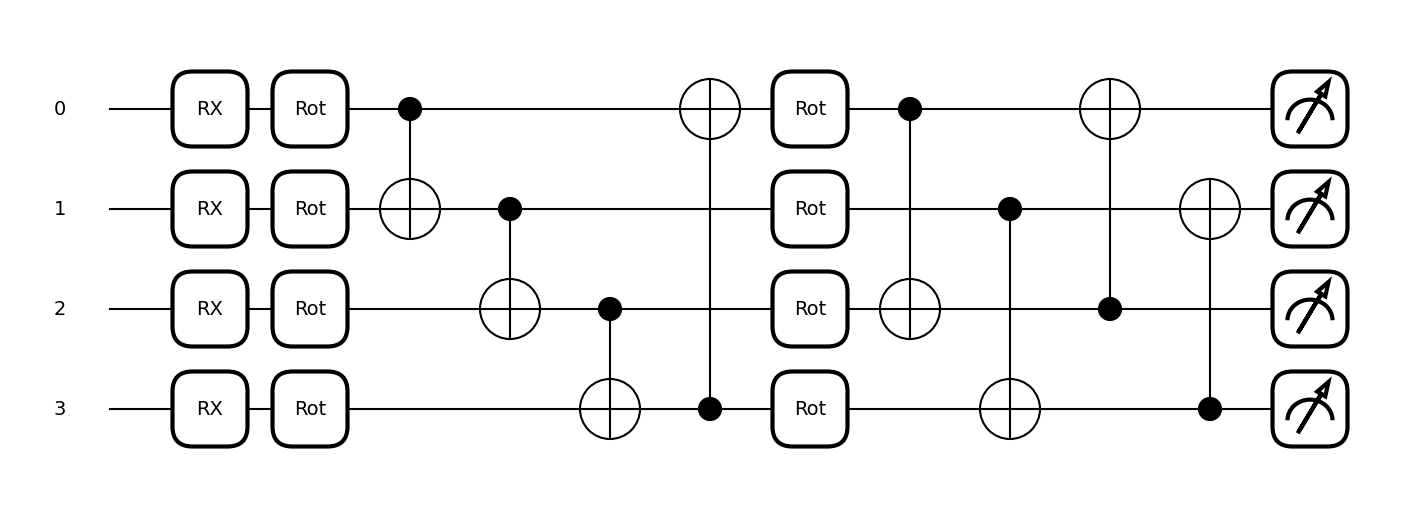

In [5]:
circuit, weight_shape = QNet.strongly_entangling_layers()
weights = torch.rand(weight_shape())
fig, ax = qml.draw_mpl(circuit, level="device")(dummy_inputs, weights)
plt.show()

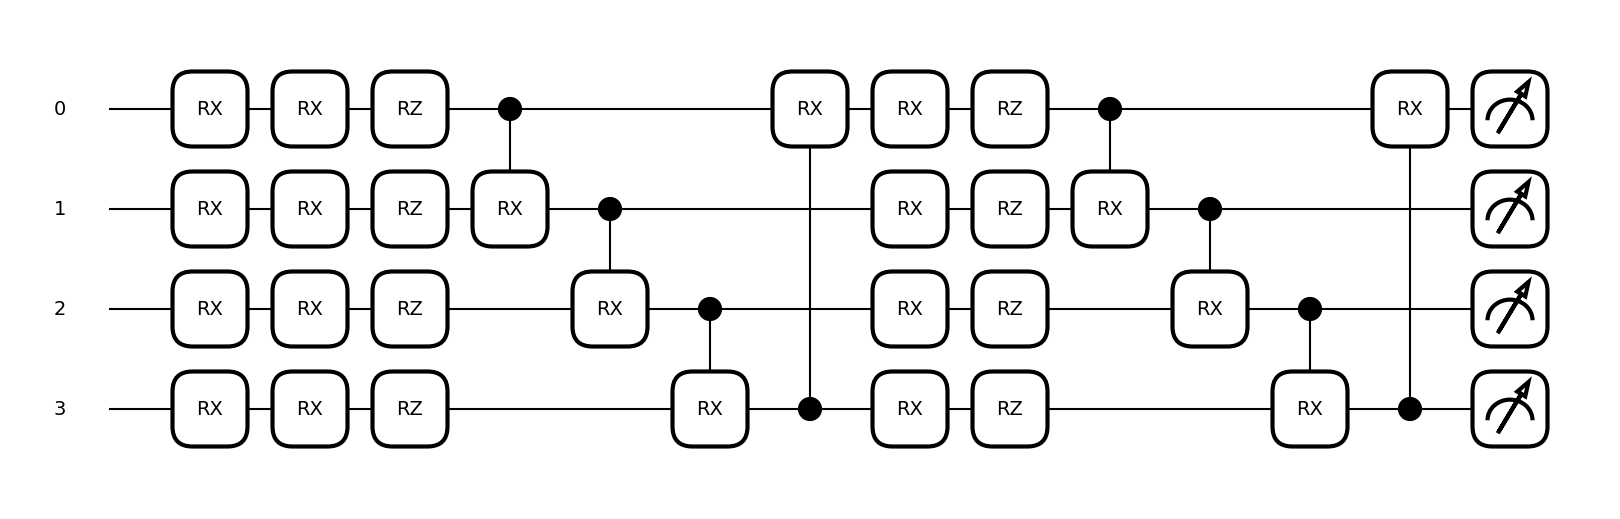

In [6]:
circuit, weight_shape = QNet.cascading_layers()
weights = torch.rand(weight_shape())
fig, ax = qml.draw_mpl(circuit, level="device")(dummy_inputs, weights)
plt.show()

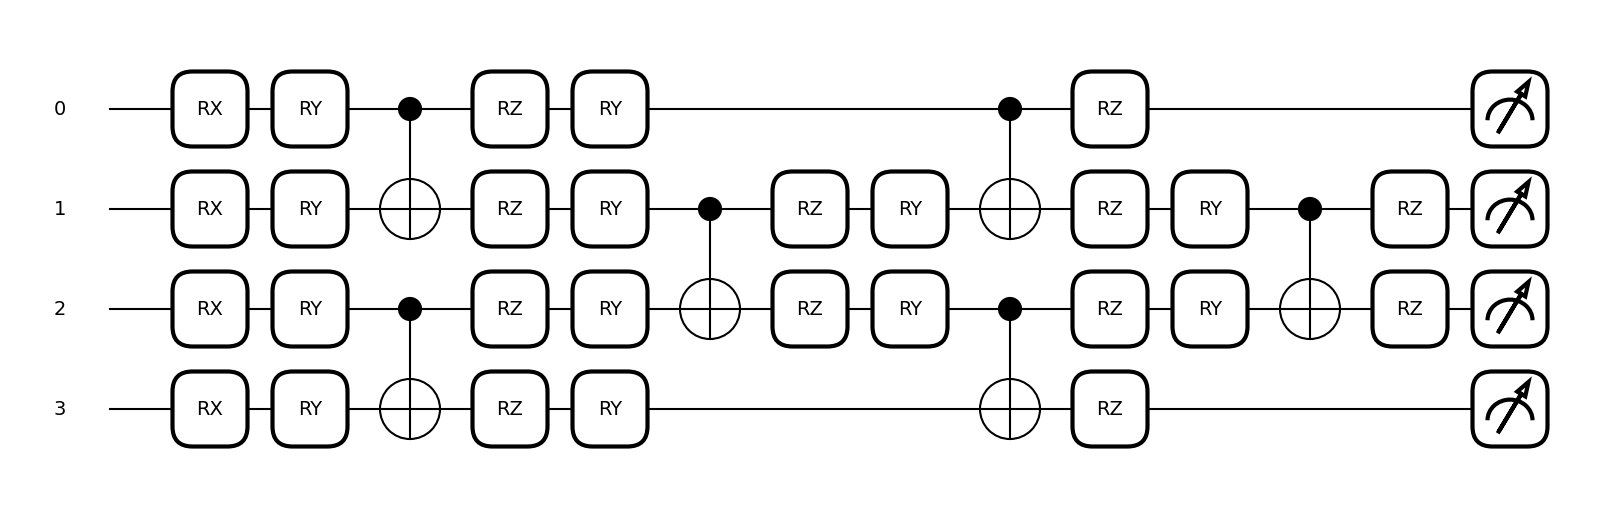

In [7]:
circuit, weight_shape = QNet.alternating_layers()
weights = torch.rand(weight_shape())
fig, ax = qml.draw_mpl(circuit, level="device")(dummy_inputs, weights)
plt.show()

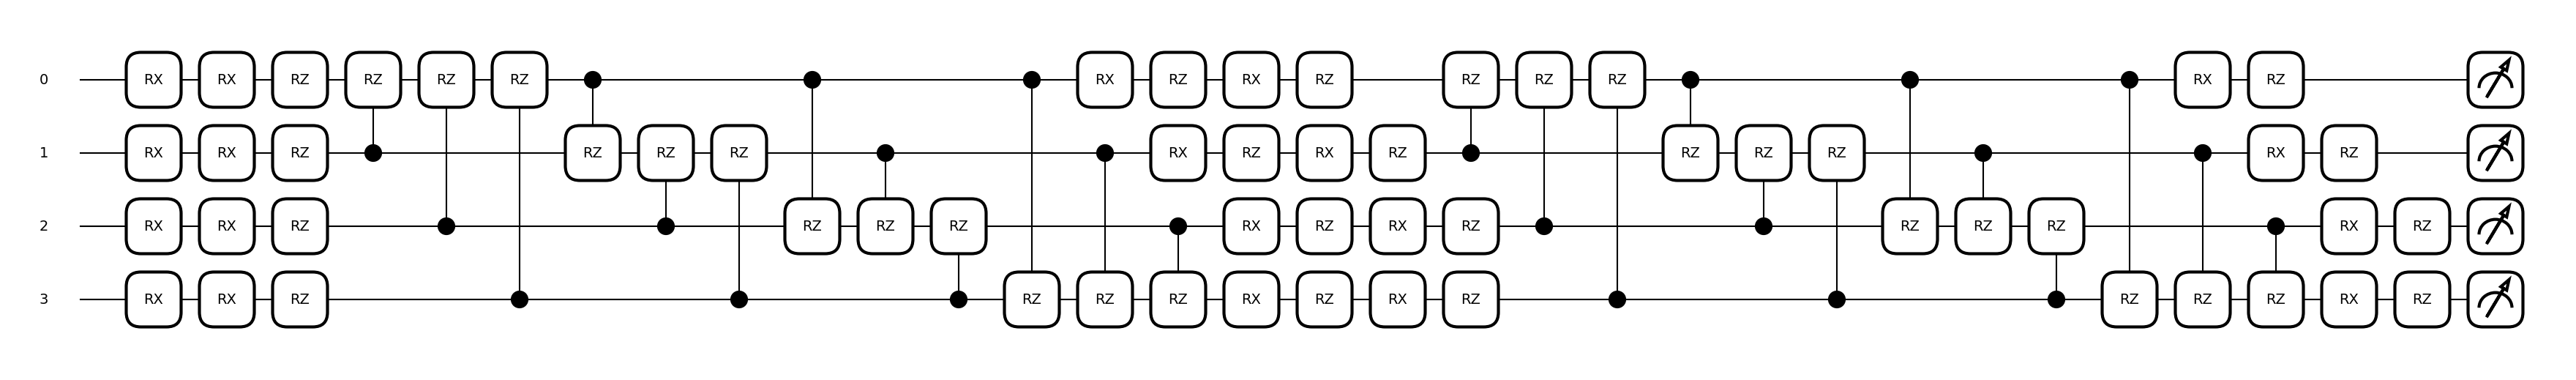

In [8]:
circuit, weight_shape = QNet.cross_meshed_layers()
weights = torch.rand(weight_shape())
fig, ax = qml.draw_mpl(circuit, level="device")(dummy_inputs, weights)
plt.show()

In [9]:
class HybridQPINN(nn.Module):
    def __init__(self, q_layers: QuantumNet, hidden_dim: int = 32):
        super().__init__()
        self.quantum = q_layers

        self.embedding = nn.Sequential(
            nn.Linear(2, q_layers.n_qubits),
            nn.Tanh(),
        )

        self.decoding = nn.Sequential(
            nn.Linear(q_layers.n_qubits, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 2),
        )

        # check once with and once without this
        # for nets in [self.embedding, self.decoding]:
        #     for m in nets:
        #         if isinstance(m, nn.Linear):
        #             nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
        #             nn.init.zeros_(m.bias)

    def forward(self, x):
        embedding_device = next(self.embedding.parameters()).device
        quantum_device = next(self.quantum.parameters()).device
        decoding_device = next(self.decoding.parameters()).device

        x = self.embedding(x.to(embedding_device))
        x = self.quantum(x.to(quantum_device))
        return self.decoding(x.to(decoding_device))

In [10]:
from typing import Optional


def make_hybrid_qpinn(
    n_qubits: int,
    n_layers: int,
    layer_type: str,
    device_type: str = "default.qubit",
    shots: Optional[int] = None,
    hidden_dim: int = 32,
) -> HybridQPINN:
    q_layers = QuantumNet(n_qubits=n_qubits, n_layers=n_layers)
    q_layers.set_device(device_type, shots=shots)
    q_layers.make_circuit(layer_type)

    model = HybridQPINN(q_layers=q_layers, hidden_dim=hidden_dim)
    model.embedding.to(classic_device)
    model.decoding.to(classic_device)

    quantum_torch_device = (
        classic_device
        if classic_device.type == "cuda" and any(tag in device_type for tag in ("gpu", "cuda"))
        else torch.device("cpu")
    )
    model.quantum.to(quantum_torch_device)
    return model


def qpinn_param_breakdown(
    n_qubits: int,
    n_layers: int,
    layer_type: str,
    device_type: str = "default.qubit",
    shots: Optional[int] = None,
    hidden_dim: int = 32,
) -> dict[str, int]:
    def count_trainable_params(module: nn.Module) -> int:
        return sum(p.numel() for p in module.parameters() if p.requires_grad)

    model = make_hybrid_qpinn(
        n_qubits, n_layers, layer_type, device_type, shots, hidden_dim
    )
    breakdown = {
        "embedding": count_trainable_params(model.embedding),
        "quantum": count_trainable_params(model.quantum),
        "decoding": count_trainable_params(model.decoding),
    }
    breakdown["total"] = sum(breakdown.values())
    return breakdown

In [11]:
N_QUBITS = 6
N_LAYERS = 3
ARCHITECTURE = "cascading"
DEVICE_TYPE = "default.qubit"

SHOTS = None
HIDDEN_DIM = 32

N_TRAIN, N_TEST = 256, 128
U0, RE, RHO = 1.0, 100, 1.0

layer_types = ["strongly_entangling", "cascading", "alternating", "cross_meshed"]

rows = []
for layer_type in layer_types:
    breakdown = qpinn_param_breakdown(
        n_qubits=N_QUBITS,
        n_layers=N_LAYERS,
        shots=SHOTS,
        layer_type=layer_type,
        hidden_dim=HIDDEN_DIM,
    )
    rows.append({"layer_type": layer_type, **breakdown})

param_table = pd.DataFrame(rows)[["layer_type", "embedding", "quantum", "decoding", "total"]]
param_table.style.hide(axis="index")

layer_type,embedding,quantum,decoding,total
strongly_entangling,18,54,290,362
cascading,18,54,290,362
alternating,18,72,290,380
cross_meshed,18,612,290,920


In [12]:
def d_(f, v):
    return torch.autograd.grad(
        f, v, grad_outputs=torch.ones_like(f), create_graph=True
    )[0]


def model_grads(model, xy):
    out = model(xy.to(classic_device))
    psi = out[:, :1]
    p = out[:, 1:2]

    grad_psi = d_(psi, xy)
    u = grad_psi[:, 1:2]
    v = -grad_psi[:, 0:1]

    grad_p = d_(p, xy)
    p_x = grad_p[:, 0:1]
    p_y = grad_p[:, 1:2]

    grad_u = d_(u, xy)
    u_x = grad_u[:, 0:1]
    u_y = grad_u[:, 1:2]
    u_xx = d_(u_x, xy)[:, 0:1]
    u_yy = d_(u_y, xy)[:, 1:2]

    grad_v = d_(v, xy)
    v_x = grad_v[:, 0:1]
    v_y = grad_v[:, 1:2]
    v_xx = d_(v_x, xy)[:, 0:1]
    v_yy = d_(v_y, xy)[:, 1:2]

    return {
        "psi": psi,
        "p": p,
        "u": u,
        "v": v,
        "p_x": p_x,
        "p_y": p_y,
        "u_x": u_x,
        "u_y": u_y,
        "u_xx": u_xx,
        "u_yy": u_yy,
        "v_x": v_x,
        "v_y": v_y,
        "v_xx": v_xx,
        "v_yy": v_yy,
    }


def pde_residuals(fields, rho=1.0, nu=0.01):
    u, v = fields["u"], fields["v"]
    u_x, u_y = fields["u_x"], fields["u_y"]
    v_x, v_y = fields["v_x"], fields["v_y"]
    p_x, p_y = fields["p_x"], fields["p_y"]
    u_xx, u_yy = fields["u_xx"], fields["u_yy"]
    v_xx, v_yy = fields["v_xx"], fields["v_yy"]

    mom_x = u * u_x + v * u_y + p_x / rho - nu * (u_xx + u_yy)
    mom_y = u * v_x + v * v_y + p_y / rho - nu * (v_xx + v_yy)
    return mom_x, mom_y

In [ ]:
mse = nn.MSELoss() # is mse the best metric?

def compute_loss(model, xy_eqn, xy_bnd, uv_bnd, rho=1.0, nu=0.01):
    fields_eqn = model_grads(model, xy_eqn)
    mom_x, mom_y = pde_residuals(fields_eqn, rho=rho, nu=nu)
    loss_eqn = mse(mom_x, torch.zeros_like(mom_x)) + mse(
        mom_y, torch.zeros_like(mom_y)
    )

    fields_bnd = model_grads(model, xy_bnd)
    psi_bc = fields_bnd["psi"]
    uv_bc = torch.cat([fields_bnd["u"], fields_bnd["v"]], dim=1).to(classic_device)
    loss_psi = mse(psi_bc, torch.zeros_like(psi_bc))
    loss_uv = mse(uv_bc, uv_bnd)

    loss = loss_eqn + loss_psi + loss_uv
    return loss

In [14]:
def generate_bc_points(n_total: int) -> np.ndarray:
    n = n_total // 4
    top = np.hstack([np.random.rand(n, 1), np.ones((n, 1))])
    bottom = np.hstack([np.random.rand(n, 1), np.zeros((n, 1))])
    left = np.hstack([np.zeros((n, 1)), np.random.rand(n, 1)])
    right = np.hstack([np.ones((n, 1)), np.random.rand(n, 1)])
    return np.vstack([top, bottom, left, right]).astype(np.float32)


xy_bnd_np = generate_bc_points(N_TRAIN) # [points, 2]
xy_eqn_np = np.random.rand(N_TRAIN, 2).astype(np.float32)

uv_bnd_np = np.zeros((N_TRAIN, 2), dtype=np.float32)
is_top_wall = np.isclose(xy_bnd_np[:, 1], 1.0)
uv_bnd_np[is_top_wall, 0] = U0 # replace with velocity

xy_eqn = torch.tensor(xy_eqn_np, device=classic_device, requires_grad=True)
xy_bnd = torch.tensor(xy_bnd_np, device=classic_device, requires_grad=True)
uv_bnd = torch.tensor(uv_bnd_np, device=classic_device)

In [15]:
from pathlib import Path
from datetime import datetime
from copy import deepcopy
from typing import TypedDict
import os

model = make_hybrid_qpinn(
    n_qubits=N_QUBITS,
    n_layers=N_LAYERS,
    layer_type=ARCHITECTURE,
    device_type=DEVICE_TYPE,
    hidden_dim=HIDDEN_DIM,
    shots=SHOTS,
)

class ModelState(TypedDict):
    embedding: dict[str, torch.Tensor]
    quantum: dict[str, torch.Tensor]
    decoding: dict[str, torch.Tensor]

class ModelSave:
    SAVE_DIR_NAME = "saved_models"

    def __init__(self):
        file = os.path.dirname(os.path.abspath("__file__"))
        self.save_dir = Path(file).joinpath(self.SAVE_DIR_NAME)
        self.save_dir.mkdir(exist_ok=True)

    def generate_save_path(self, suffix: Optional[str] = None) -> str:
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        model_name = f"hybrid-qpinn-v2-{timestamp}"
        if suffix:
            model_name += f"-{suffix}"
        return str(self.save_dir.joinpath(model_name + ".pt"))

    @staticmethod
    def snapshot(model: HybridQPINN) -> ModelState:
        return {
            "embedding": deepcopy(model.embedding.state_dict()),
            "quantum": deepcopy(model.quantum.state_dict()),
            "decoding": deepcopy(model.decoding.state_dict()),
        }

    @staticmethod
    def restore(model: HybridQPINN, model_state: ModelState):
        model.embedding.load_state_dict(model_state["embedding"])
        model.quantum.load_state_dict(model_state["quantum"])
        model.decoding.load_state_dict(model_state["decoding"])

    @staticmethod
    def update_best(
        model: HybridQPINN,
        loss: float,
        old_loss: float,
        old_state: Optional[ModelState],
    ) -> tuple[float, Optional[ModelState]]:
        if loss < old_loss:
            return loss, ModelSave.snapshot(model)
        return old_loss, old_state

    @staticmethod
    def save(model: HybridQPINN, path: str):
        model_state = ModelSave.snapshot(model)

        torch.save(model_state, path)
        print(f"Model saved to {path}")

    @staticmethod
    def load(path: str):
        if not os.path.exists(path):
            raise FileNotFoundError(f"No model found at {path}")

        new_model = make_hybrid_qpinn(
            n_qubits=N_QUBITS,
            n_layers=N_LAYERS,
            layer_type=ARCHITECTURE,
            device_type=DEVICE_TYPE,
            hidden_dim=HIDDEN_DIM,
            shots=SHOTS,
        )

        model_state = torch.load(path, map_location=classic_device)
        ModelSave.restore(new_model, model_state)
        print(f"Model loaded from {path}")
        return new_model

In [ ]:
from typing import List, NotRequired


class AdamParams(TypedDict):
    adam_iters: int
    adam_lr: NotRequired[float]
    clip_grad: NotRequired[float]
    batch_size: NotRequired[int]


def use_adam_optimizer(
    model: HybridQPINN,
    history: List[float],
    adam_params: AdamParams,
    xy_eqn: torch.Tensor,
    xy_bnd: torch.Tensor,
    uv_bnd: torch.Tensor,
    print_every=100,
) -> List[float]:
    adam_lr = adam_params.get("adam_lr", 1e-3)
    adam = torch.optim.Adam(model.parameters(), lr=adam_lr)
    n_eqn = xy_eqn.shape[0]
    n_bnd = xy_bnd.shape[0]
    best_loss, best_state = float("inf"), None

    def minibatch_sampling(batch_size: int):
        index_eqn = torch.randint(
            0, n_eqn, (min(batch_size, n_eqn),), device=xy_eqn.device
        )
        index_bnd = torch.randint(
            0, n_bnd, (min(batch_size, n_bnd),), device=xy_bnd.device
        )

        xy_eqn_batch = xy_eqn[index_eqn].detach().requires_grad_(True)
        xy_bnd_batch = xy_bnd[index_bnd].detach().requires_grad_(True)
        uv_bnd_batch = uv_bnd[index_bnd]

        return xy_eqn_batch, xy_bnd_batch, uv_bnd_batch

    for i in range(adam_params["adam_iters"]):
        adam.zero_grad()
        xy_eqn_batch, xy_bnd_batch, uv_bnd_batch = minibatch_sampling(
            batch_size=adam_params.get("batch_size", 256)
        )
        loss = compute_loss(
            model, xy_eqn_batch, xy_bnd_batch, uv_bnd_batch, RHO, 1 / RE
        )

        loss_value = float(loss.detach().item())
        best_loss, best_state = ModelSave.update_best(
            model, loss_value, best_loss, best_state
        )

        loss.backward()
        clip_grad = adam_params.get("clip_grad", None)
        if clip_grad is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        adam.step()

        history.append(loss_value)
        if (i + 1) % print_every == 0 or i == 0:
            print(f"[Adam {i + 1}/{adam_params['adam_iters']}] loss={loss_value:.4e}")

    if best_state is not None:
        ModelSave.restore(model, best_state)

    return history

In [17]:
class LBFGSParams(TypedDict):
    lbfgs_iters: int
    lbfgs_lr: NotRequired[float]


def use_lbfgs_optimizer(
    model: HybridQPINN,
    history: List[float],
    lbfgs_params: LBFGSParams,
    xy_eqn: torch.Tensor,
    xy_bnd: torch.Tensor,
    uv_bnd: torch.Tensor,
    print_every=10,
) -> List[float]:
    lbfgs_iters = lbfgs_params["lbfgs_iters"]
    params = [p for p in model.parameters() if p.requires_grad]
    best_loss = float("inf")
    best_state = None

    lbfgs = torch.optim.LBFGS(
        params,
        lr=lbfgs_params.get("lbfgs_lr", 1),
        line_search_fn="strong_wolfe",
    )

    def closure():
        model.zero_grad(set_to_none=True)  # performance opt
        loss = compute_loss(model, xy_eqn, xy_bnd, uv_bnd, RHO, 1 / RE)
        loss.backward()
        return loss

    for i in range(lbfgs_iters):
        loss = lbfgs.step(closure)
        loss_value = float(loss.detach().item())
        best_loss, best_state = ModelSave.update_best(
            model, loss_value, best_loss, best_state
        )

        history.append(loss_value)
        if (i + 1) % print_every == 0 or i == 0:
            print(f"[LBFGS {i + 1}/{lbfgs_iters}] loss={loss_value:.4e}")

        if not np.isfinite(loss_value):
            print(f"[LBFGS] non-finite loss at iter {i + 1}; stopping.")
            break

    if best_state is not None:
        ModelSave.restore(model, best_state)

    return history

In [18]:
def train_qpinn(
    model: HybridQPINN,
    adam_params: AdamParams,
    lbfgs_params: LBFGSParams,
    xy_eqn: torch.Tensor,
    xy_bnd: torch.Tensor,
    uv_bnd: torch.Tensor,
    model_manager: Optional[ModelSave] = None,
) -> List[float]:
    history = []

    history = use_adam_optimizer(
        model,
        [],  # no history as it starts with adam
        adam_params,
        xy_eqn=xy_eqn,
        xy_bnd=xy_bnd,
        uv_bnd=uv_bnd,
    )

    print("[Adam] Optimizer ran.", end=" ")
    if model_manager:
        save_path = model_manager.generate_save_path(suffix="post-adam")
        model_manager.save(model, save_path)
    else:
        print("[Adam] No model manager provided, skipping save.")

    history = use_lbfgs_optimizer(
        model,
        history,
        lbfgs_params,
        xy_eqn=xy_eqn,
        xy_bnd=xy_bnd,
        uv_bnd=uv_bnd,
    )

    print("[LBFGS] Optimizer ran.", end=" ")
    if model_manager:
        save_path = model_manager.generate_save_path(suffix="post-lbfgs")
        model_manager.save(model, save_path)
    else:
        print("[LBFGS] No model manager provided, skipping save.")

    final_loss = compute_loss(model, xy_eqn, xy_bnd, uv_bnd, RHO, 1 / RE)
    print(f"Final loss after training: {final_loss:.4e}")

    return history


loss_history = train_qpinn(
    model,
    adam_params={
        "adam_iters": 1000,
        "adam_lr": 1e-3,
        "clip_grad": 1.0,
        "batch_size": 64,
    },
    lbfgs_params={"lbfgs_iters": 50},
    xy_eqn=xy_eqn,
    xy_bnd=xy_bnd,
    uv_bnd=uv_bnd,
    model_manager=ModelSave(),
)

[Adam 1/1000] loss=1.8737e-01
[Adam 100/1000] loss=8.7017e-02
[Adam 200/1000] loss=5.2300e-02
[Adam 300/1000] loss=5.5430e-02
[Adam 400/1000] loss=4.9232e-02
[Adam 500/1000] loss=3.3317e-02
[Adam 600/1000] loss=2.8864e-02
[Adam 700/1000] loss=3.1402e-02
[Adam 800/1000] loss=2.9388e-02
[Adam 900/1000] loss=2.2688e-02
[Adam 1000/1000] loss=3.2160e-02
[Adam] Optimizer ran. Model saved to /home/prantik/projects/qsnippets/06_explore_qpinns/te-qpinns/saved_models/hybrid-qpinn-v2-2026-06-08_17-12-26-post-adam.pt
[LBFGS 1/50] loss=2.7503e-02
[LBFGS 10/50] loss=1.1246e-02
[LBFGS 20/50] loss=1.0763e-02
[LBFGS 30/50] loss=1.0567e-02
[LBFGS 40/50] loss=1.0316e-02
[LBFGS 50/50] loss=1.0118e-02
[LBFGS] Optimizer ran. Model saved to /home/prantik/projects/qsnippets/06_explore_qpinns/te-qpinns/saved_models/hybrid-qpinn-v2-2026-06-08_17-47-32-post-lbfgs.pt
Final loss after training: 1.0089e-02


In [19]:
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec


def contour(grid, x, y, z, title, levels=40):
    vmin, vmax = z.min(), z.max()
    plt.subplot(grid)
    plt.contour(x, y, z, colors="k", linewidths=0.2, levels=levels)
    plt.contourf(
        x, y, z, cmap="rainbow", levels=levels,
        norm=Normalize(vmin=vmin, vmax=vmax),
    )
    plt.title(title)
    cbar = plt.colorbar(pad=0.03, aspect=25, format="%.0e")
    cbar.mappable.set_clim(vmin, vmax)


def model_predict(model, xy, chunk_size=256):
    psi_list, p_list, u_list, v_list = [], [], [], []

    for start in range(0, xy.shape[0], chunk_size):
        xy_chunk = xy[start : start + chunk_size].detach().requires_grad_(True)

        out = model(xy_chunk.to(classic_device))
        psi_c = out[:, :1]
        p_c = out[:, 1:2]

        grad_psi = torch.autograd.grad(
            psi_c,
            xy_chunk,
            grad_outputs=torch.ones_like(psi_c),
            create_graph=False,
        )[0]

        psi_list.append(psi_c.detach().cpu())
        p_list.append(p_c.detach().cpu())
        u_list.append(grad_psi[:, 1:2].detach().cpu())
        v_list.append(-grad_psi[:, 0:1].detach().cpu())

    return {
        "psi": torch.cat(psi_list),
        "p": torch.cat(p_list),
        "u": torch.cat(u_list),
        "v": torch.cat(v_list),
    }


# Prediction grid
x_lin = np.linspace(0, 1, N_TEST, dtype=np.float32)
y_lin = np.linspace(0, 1, N_TEST, dtype=np.float32)
X, Y = np.meshgrid(x_lin, y_lin)
XY = np.stack([X.ravel(), Y.ravel()], axis=1)

xy_test = torch.tensor(XY, device=classic_device)
fields = model_predict(model, xy_test, chunk_size=256)

psi = fields["psi"].numpy().reshape(X.shape)
p = fields["p"].numpy().reshape(X.shape)
u = fields["u"].numpy().reshape(X.shape)
v = fields["v"].numpy().reshape(X.shape)

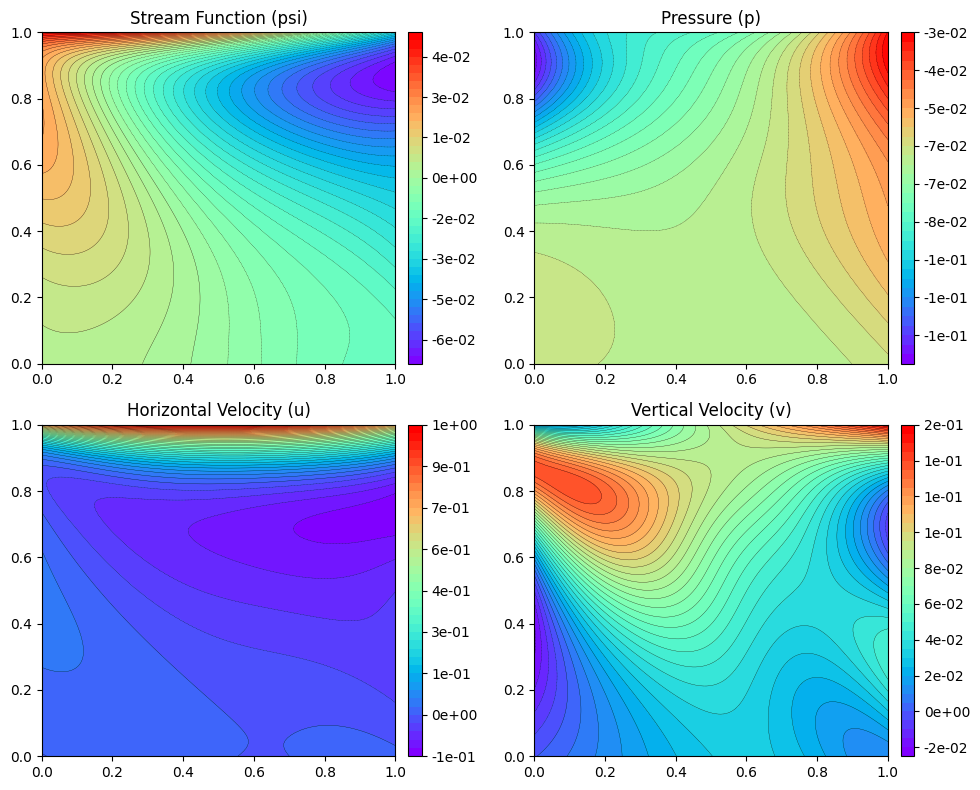

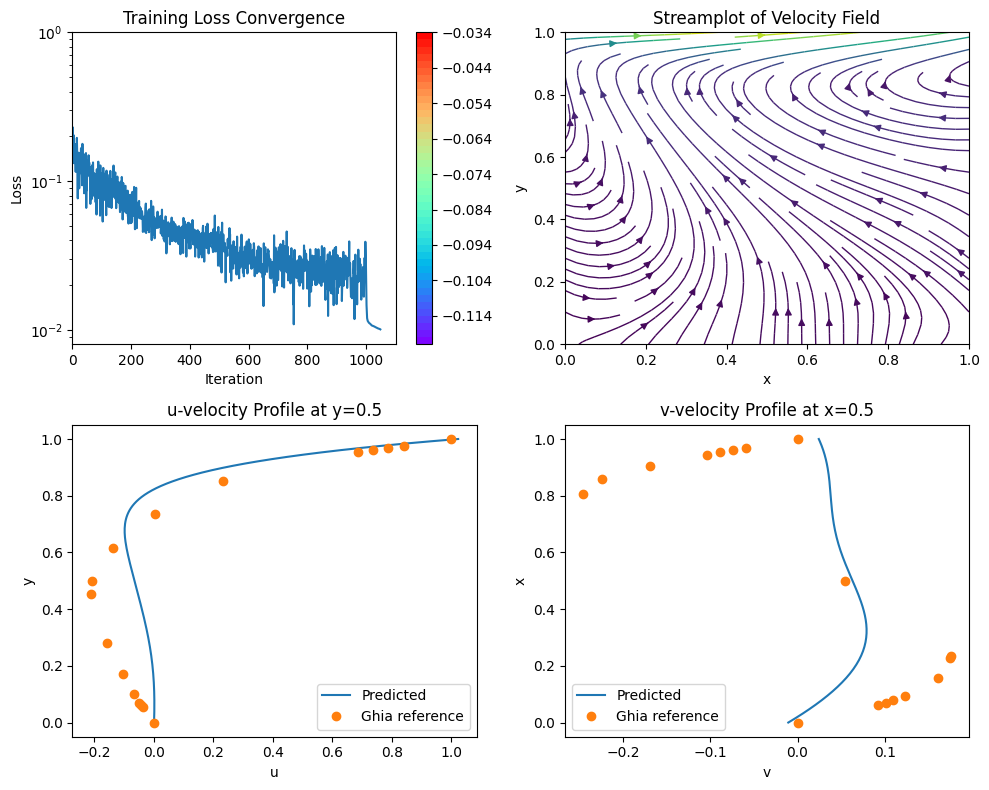

In [20]:
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2)
contour(gs[0, 0], X, Y, psi, "Stream Function (psi)")
contour(gs[0, 1], X, Y, p, "Pressure (p)")
contour(gs[1, 0], X, Y, u, "Horizontal Velocity (u)")
contour(gs[1, 1], X, Y, v, "Vertical Velocity (v)")
plt.tight_layout()
plt.show()

# Ghia reference (u along x=0.5, Re=100)
y_u_Re100 = np.array(
    [
        1.0000,
        0.9766,
        0.9688,
        0.9609,
        0.9531,
        0.8516,
        0.7344,
        0.6172,
        0.5000,
        0.4531,
        0.2813,
        0.1719,
        0.1016,
        0.0703,
        0.0625,
        0.0547,
        0.0000,
    ],
    dtype=np.float32,
)
u_Re100 = np.array(
    [
        1.00000,
        0.84123,
        0.78871,
        0.73722,
        0.68717,
        0.23151,
        0.00332,
        -0.13641,
        -0.20581,
        -0.21090,
        -0.15662,
        -0.10150,
        -0.06434,
        -0.04775,
        -0.04192,
        -0.03717,
        0.00000,
    ],
    dtype=np.float32,
)
x_v_Re100 = np.array(
    [
        1.0000,
        0.9688,
        0.9609,
        0.9531,
        0.9453,
        0.9063,
        0.8594,
        0.8047,
        0.5000,
        0.2344,
        0.2266,
        0.1563,
        0.0938,
        0.0781,
        0.0703,
        0.0625,
        0.0000
    ],
    dtype=np.float32,
)
v_Re100 = np.array(
    [
        0.00000,
        -0.05906,
        -0.07391,
        -0.08864,
        -0.10313,
        -0.16914,
        -0.22445,
        -0.24533,
        0.05454,
        0.17527,
        0.17507,
        0.16077,
        0.12317,
        0.10890,
        0.10091,
        0.09233,
        0.00000
    ],
    dtype=np.float32,
)


fig, axs = plt.subplots(2, 2, figsize=(10, 8))
cf = axs[0, 0].contourf(X, Y, p, levels=50, cmap="rainbow")
plt.colorbar(cf, ax=axs[0, 0])
stride = 5

axs[0, 0].semilogy(loss_history)
axs[0, 0].set_title("Training Loss Convergence")
axs[0, 0].set_xlabel("Iteration")
axs[0, 0].set_ylabel("Loss")

axs[0, 1].streamplot(
    X, Y, u, v, color=np.sqrt(u**2 + v**2), cmap="viridis", linewidth=1
)
axs[0, 1].set_title("Streamplot of Velocity Field")
axs[0, 1].set_xlabel("x")
axs[0, 1].set_ylabel("y")

mid_x = np.argmin(np.abs(x_lin - 0.5))
axs[1, 0].plot(u[:, mid_x], y_lin, label="Predicted")
axs[1, 0].plot(u_Re100, y_u_Re100, "o", label="Ghia reference")
axs[1, 0].set_title("u-velocity Profile at y=0.5")
axs[1, 0].set_xlabel("u")
axs[1, 0].set_ylabel("y")
axs[1, 0].legend()

mid_y = np.argmin(np.abs(y_lin - 0.5))
axs[1, 1].plot(v[mid_y, :], x_lin, label="Predicted")
axs[1, 1].plot(v_Re100, x_v_Re100, "o", label="Ghia reference")
axs[1, 1].set_title("v-velocity Profile at x=0.5")
axs[1, 1].set_xlabel("v")
axs[1, 1].set_ylabel("x")
axs[1, 1].legend()

plt.tight_layout()
plt.show()